In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
n = 20
df = pd.DataFrame({
    "student_id"  : range(1, n+1),
    "student_name": ["Aarav","Priya","Rohan","Sneha","Kiran","Anjali","Vikram","Pooja","Arjun","Divya",
                     "Rahul","Meera","Suresh","Lakshmi","Nikhil","Kavya","Aditya","Nisha","Raj","Simran"],
    "age"         : [20,21,np.nan,22,20,21,23,np.nan,20,22,21,20,19,23,22,np.nan,21,19,22,20],
    "height"      : [165,170,160,175,np.nan,210,172,163,169,174,167,171,120,166,np.nan,168,np.nan,164,172,169],
    "weight"      : [np.nan,65,55,70,62,68,130,58,np.nan,66,61,67,54,72,63,59,64,np.nan,71,60],
    "semester"    : [3,4,2,5,3,np.nan,6,2,3,np.nan,4,3,2,6,np.nan,3,4,np.nan,5,3],
    "gender"      : ["M","F","M","F","M","F","M","F","M","F","M","F","M","F","M","F","M","F","M","F"],
    "city"        : ["Delhi","Mumbai","Bangalore","Chennai","Hyderabad","Pune","Delhi","Mumbai","Bangalore","Chennai",
                     "Jaipur","Pune","Delhi","Mumbai","Hyderabad","Bangalore","Chennai","Jaipur","Pune","Delhi"]
})
print(df)

    student_id student_name   age  height  weight  semester gender       city
0            1        Aarav  20.0   165.0     NaN       3.0      M      Delhi
1            2        Priya  21.0   170.0    65.0       4.0      F     Mumbai
2            3        Rohan   NaN   160.0    55.0       2.0      M  Bangalore
3            4        Sneha  22.0   175.0    70.0       5.0      F    Chennai
4            5        Kiran  20.0     NaN    62.0       3.0      M  Hyderabad
5            6       Anjali  21.0   210.0    68.0       NaN      F       Pune
6            7       Vikram  23.0   172.0   130.0       6.0      M      Delhi
7            8        Pooja   NaN   163.0    58.0       2.0      F     Mumbai
8            9        Arjun  20.0   169.0     NaN       3.0      M  Bangalore
9           10        Divya  22.0   174.0    66.0       NaN      F    Chennai
10          11        Rahul  21.0   167.0    61.0       4.0      M     Jaipur
11          12        Meera  20.0   171.0    67.0       3.0     

In [38]:
#Shape
print("Shape:", df.shape)

Shape: (20, 8)


In [39]:
#Column Names
print(df.columns)

Index(['student_id', 'student_name', 'age', 'height', 'weight', 'semester',
       'gender', 'city'],
      dtype='object')


In [40]:
#Null Values 
print(df.isnull().sum())

student_id      0
student_name    0
age             3
height          3
weight          3
semester        4
gender          0
city            0
dtype: int64


In [41]:
# Unique Names
print(df["student_name"].unique())

['Aarav' 'Priya' 'Rohan' 'Sneha' 'Kiran' 'Anjali' 'Vikram' 'Pooja' 'Arjun'
 'Divya' 'Rahul' 'Meera' 'Suresh' 'Lakshmi' 'Nikhil' 'Kavya' 'Aditya'
 'Nisha' 'Raj' 'Simran']


Text(0, 0.5, 'Age')

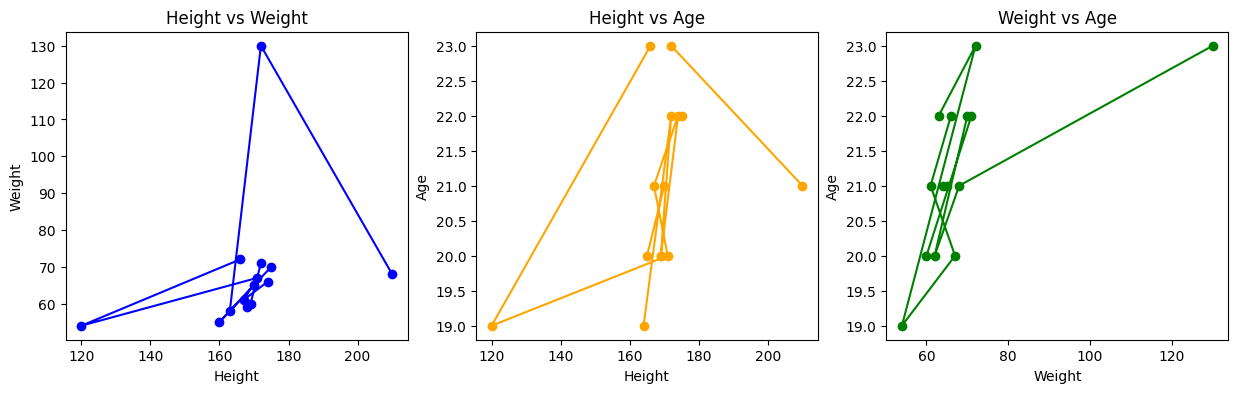

In [42]:
# Line Graphs
plt.figure(figsize=(15, 4))
 
plt.subplot(1, 3, 1)
plt.plot(df["height"], df["weight"], marker="o", color="blue")
plt.title("Height vs Weight")
plt.xlabel("Height")
plt.ylabel("Weight")
 
plt.subplot(1, 3, 2)
plt.plot(df["height"], df["age"], marker="o", color="orange")
plt.title("Height vs Age")
plt.xlabel("Height") 
plt.ylabel("Age")
 
plt.subplot(1, 3, 3)
plt.plot(df["weight"], df["age"], marker="o", color="green")
plt.title("Weight vs Age")
plt.xlabel("Weight") 
plt.ylabel("Age")

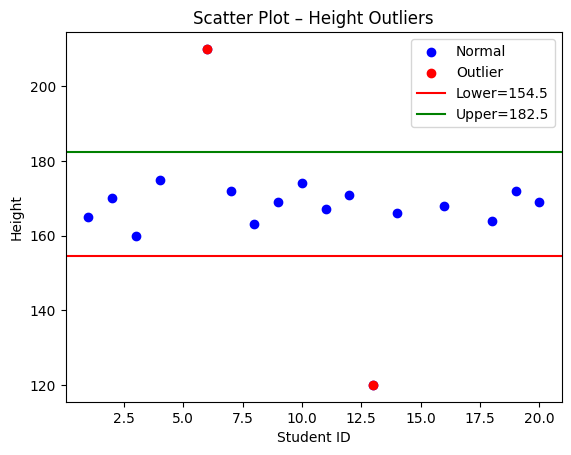

In [43]:
# Scatter Plot – Outliers in Height 
plt.scatter(df["student_id"], df["height"], color="blue", label="Normal")
 
Q1 = df["height"].quantile(0.25)
Q3 = df["height"].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
upp = Q3 + 1.5 * IQR
 
outliers = df[(df["height"] < low) | (df["height"] > upp)]
plt.scatter(outliers["student_id"], outliers["height"], color="red", label="Outlier")
plt.axhline(low, color="red",   linestyle="-", label=f"Lower={low:.1f}")
plt.axhline(upp, color="green", linestyle="-", label=f"Upper={upp:.1f}")
plt.title("Scatter Plot – Height Outliers")
plt.xlabel("Student ID")
plt.ylabel("Height")
plt.legend()

Text(0.5, 0.98, 'Boxplots – All Numeric Columns')

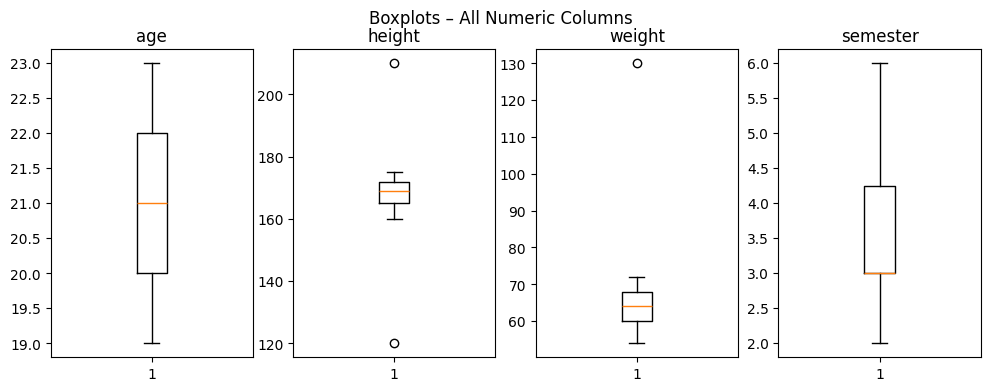

In [50]:
# Box Plots – All Columns 
plt.figure(figsize=(12, 4))
for i, col in enumerate(["age", "height", "weight", "semester"]):
    plt.subplot(1, 4, i+1)
    plt.boxplot(df[col].dropna())
    plt.title(col)
plt.suptitle("Boxplots – All Numeric Columns")

In [52]:
# Remove Outliers from Height – IQR Method 
print("Before:", len(df))
df_height = df[(df["height"] >= lower) & (df["height"] <= upper) | df["height"].isna()]
print("After :", len(df_height))

Before: 20
After : 18


In [53]:
#  Remove Outliers from Weight – Z-Score Method
print("Before:", len(df))
z = np.abs(stats.zscore(df["weight"].dropna()))
outlier_idx = df["weight"].dropna().index[z > 3]
df_weight = df.drop(index=outlier_idx)
print("After :", len(df_weight))

Before: 20
After : 19
